# Customer Segmentation & Churn Prediction System

## Objective
Analyze customer behavior, segment customers based on their characteristics,
predict customer churn using machine learning, and identify high-risk
customers for targeted retention strategies.

## Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Machine Learning Techniques
- K-Means Clustering
- Logistic Regression
- Decision Tree

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

file_path = "../Data/raw/WA_FnUseC_TelcoCustomerChurn.csv"

df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.shape

(7043, 21)

In [9]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [11]:
df["TotalCharges"].dtype

dtype('float64')

In [12]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [14]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [15]:
df.isnull().sum().sum()

0

In [16]:
df.duplicated().sum()

0

In [17]:
df["customerID"].duplicated().sum()

0

In [18]:
for col in df.select_dtypes(include="object").columns:
    print("\n", col)
    print(df[col].unique())


 customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

 gender
['Female' 'Male']

 Partner
['Yes' 'No']

 Dependents
['No' 'Yes']

 PhoneService
['No' 'Yes']

 MultipleLines
['No phone service' 'No' 'Yes']

 InternetService
['DSL' 'Fiber optic' 'No']

 OnlineSecurity
['No' 'Yes' 'No internet service']

 OnlineBackup
['Yes' 'No' 'No internet service']

 DeviceProtection
['No' 'Yes' 'No internet service']

 TechSupport
['No' 'Yes' 'No internet service']

 StreamingTV
['No' 'Yes' 'No internet service']

 StreamingMovies
['No' 'Yes' 'No internet service']

 Contract
['Month-to-month' 'One year' 'Two year']

 PaperlessBilling
['Yes' 'No']

 PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

 Churn
['No' 'Yes']


In [19]:
print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Duplicate Customer IDs:", df["customerID"].duplicated().sum())

Dataset Shape: (7043, 21)
Missing Values: 0
Duplicate Rows: 0
Duplicate Customer IDs: 0


In [20]:
df.to_csv(
    "../data/processed/telecom_churn_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [21]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [22]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


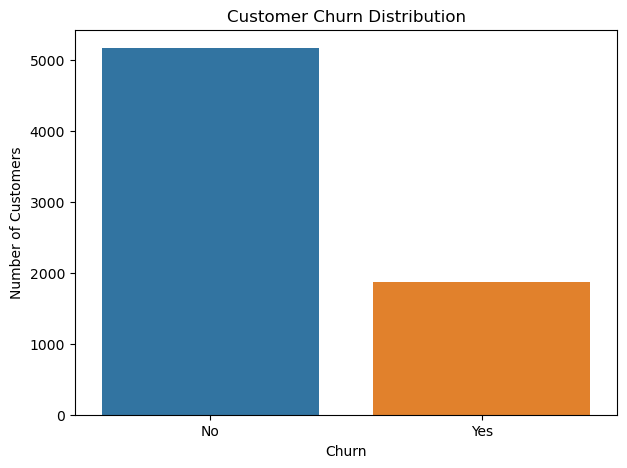

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

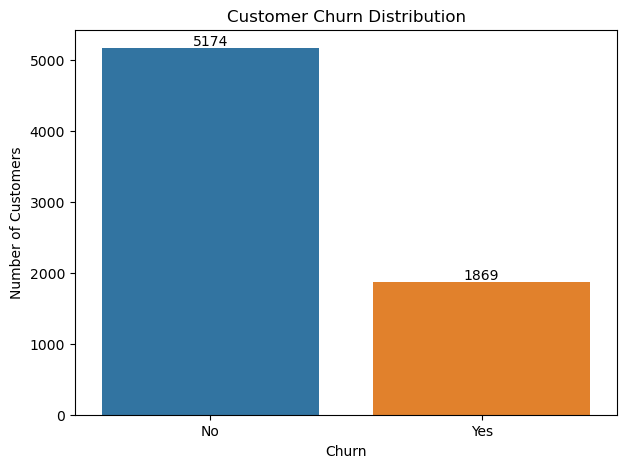

In [24]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Churn Distribution — Interpretation

The dataset contains both retained and churned customers.

The majority of customers have not churned, while approximately 26.5% of customers have churned. This indicates that customer churn is a significant business problem and justifies developing a churn prediction model.

The target variable is imbalanced because the number of non-churned customers is considerably higher than the number of churned customers. Therefore, model evaluation should consider metrics such as Precision, Recall, F1-score, and ROC-AUC rather than relying only on accuracy.

In [25]:
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


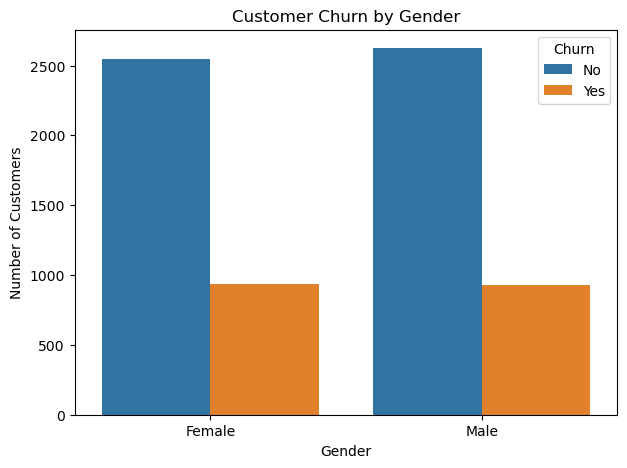

In [26]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="gender", hue="Churn")

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

In [27]:
gender_churn_rate = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

print(gender_churn_rate.round(2))

Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16


In [28]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [29]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

C:\Users\Chetan Patil\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


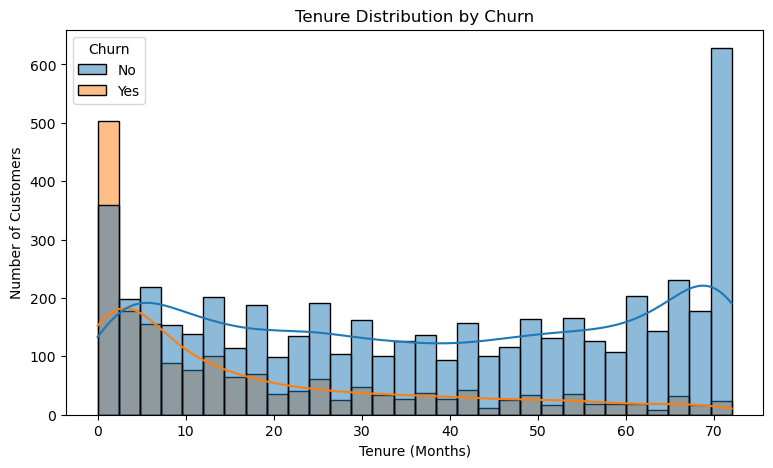

In [30]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [31]:
bins = [0, 12, 24, 36, 48, 60, 72]

labels = [
    "0-12 Months",
    "13-24 Months",
    "25-36 Months",
    "37-48 Months",
    "49-60 Months",
    "61-72 Months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [32]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

print(tenure_churn.round(2))

Churn            No    Yes
TenureGroup               
0-12 Months   52.56  47.44
13-24 Months  71.29  28.71
25-36 Months  78.37  21.63
37-48 Months  80.97  19.03
49-60 Months  85.58  14.42
61-72 Months  93.39   6.61


C:\Users\Chetan Patil\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


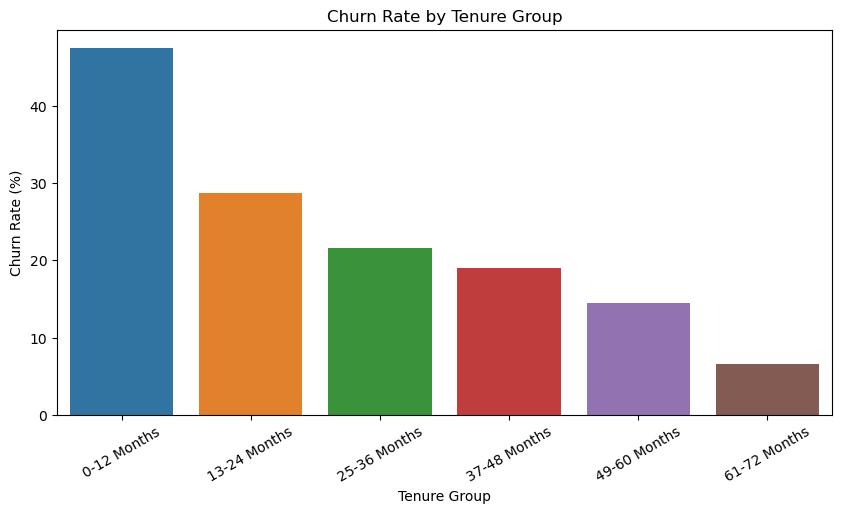

In [33]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn["Yes"]
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=30)

plt.show()

C:\Users\Chetan Patil\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


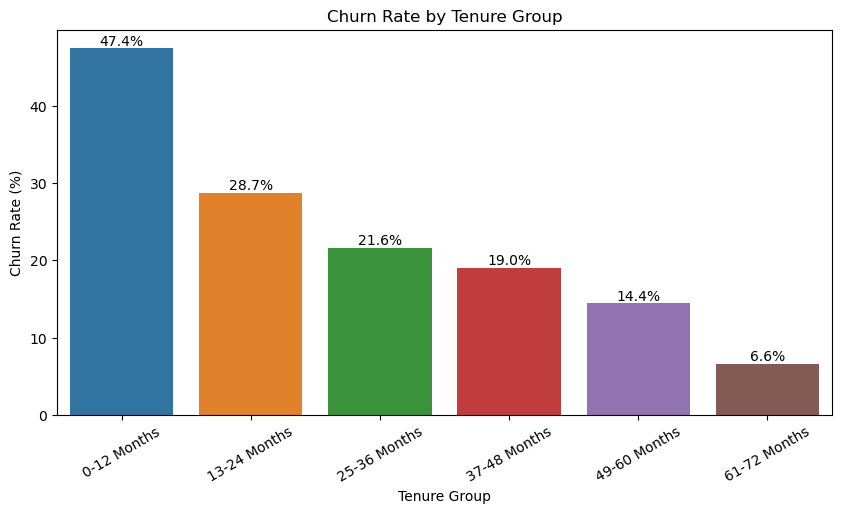

In [34]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn["Yes"]
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [35]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [36]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [37]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))


Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


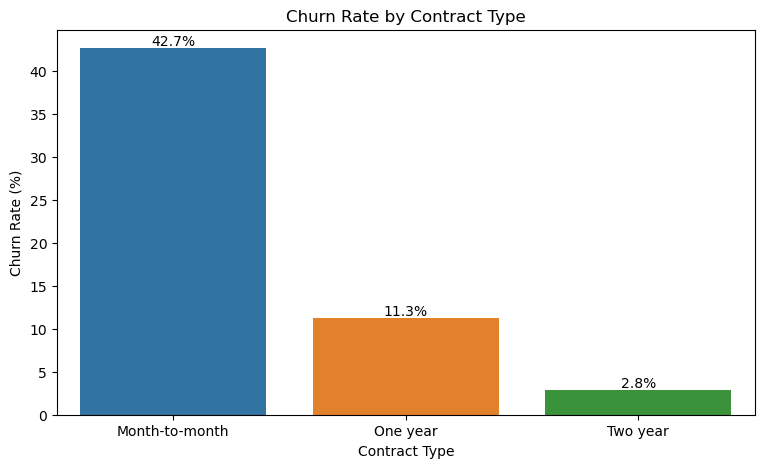

In [38]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=contract_churn.index,
    y=contract_churn["Yes"]
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Contract Type Analysis — Interpretation

Contract type shows a strong association with customer churn in the dataset.

The churn rate is 42.7% for month-to-month customers, compared with 11.3% for one-year contracts and 2.8% for two-year contracts.

This indicates that month-to-month customers represent an important group for further churn analysis. Contract type will therefore be included as an important feature in the machine learning models.

The result represents an observed association and does not by itself establish a causal relationship between contract duration and churn.

In [39]:
monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].mean()

print(monthly_charges_churn.round(2))

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


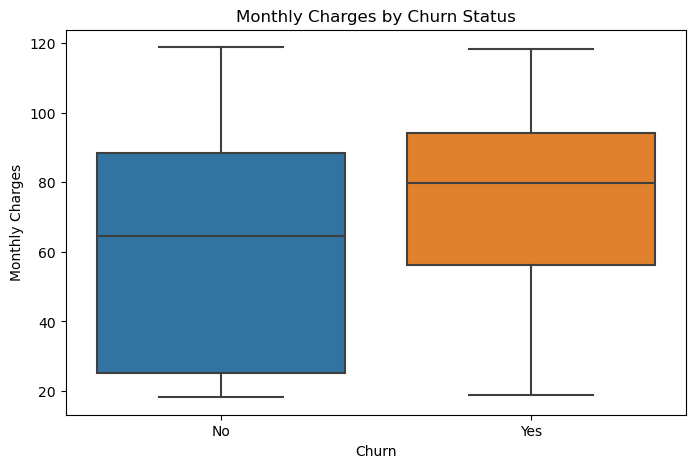

In [40]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Monthly Charges Analysis — Interpretation

Customers who churned have an average monthly charge of 74.44, compared with 61.27 for customers who did not churn.

The boxplot also shows that the distribution of monthly charges for churned customers is generally shifted toward higher values.

This indicates that MonthlyCharges has an observable association with churn and should be considered as a potential predictive feature.

However, this analysis shows association rather than causation because monthly charges may be related to other customer characteristics and services.

In [41]:
charge_bins = [0, 30, 50, 70, 90, 120]

charge_labels = [
    "0-30",
    "31-50",
    "51-70",
    "71-90",
    "91-120"
]

df["MonthlyChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=charge_bins,
    labels=charge_labels,
    include_lowest=True
)

In [42]:
charge_churn = pd.crosstab(
    df["MonthlyChargeGroup"],
    df["Churn"],
    normalize="index"
) * 100

print(charge_churn.round(2))

Churn                  No    Yes
MonthlyChargeGroup              
0-30                90.20   9.80
31-50               69.20  30.80
51-70               79.24  20.76
71-90               62.20  37.80
91-120              67.22  32.78


C:\Users\Chetan Patil\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


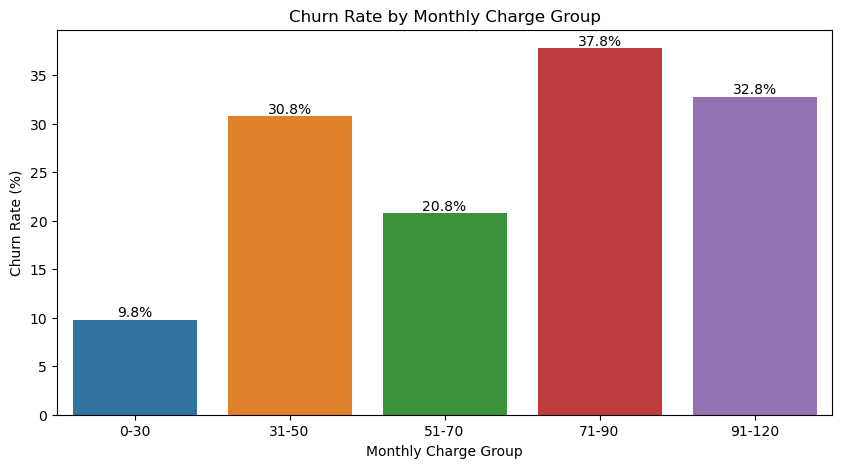

In [43]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=charge_churn.index,
    y=charge_churn["Yes"]
)

plt.title("Churn Rate by Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Monthly Charge Group Analysis — Interpretation

Churn rates vary across monthly charge groups.

The 0–30 group has the lowest observed churn rate at 9.8%, while the 71–90 group has the highest at 37.8%. The 91–120 group also shows a relatively high churn rate of 32.8%.

The relationship between monthly charges and churn is not strictly linear. Therefore, monthly charges should be analyzed together with other customer characteristics such as contract type, tenure, internet service, and payment method.

These results represent observed associations within the dataset and do not establish causation.

In [44]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn.round(2))

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


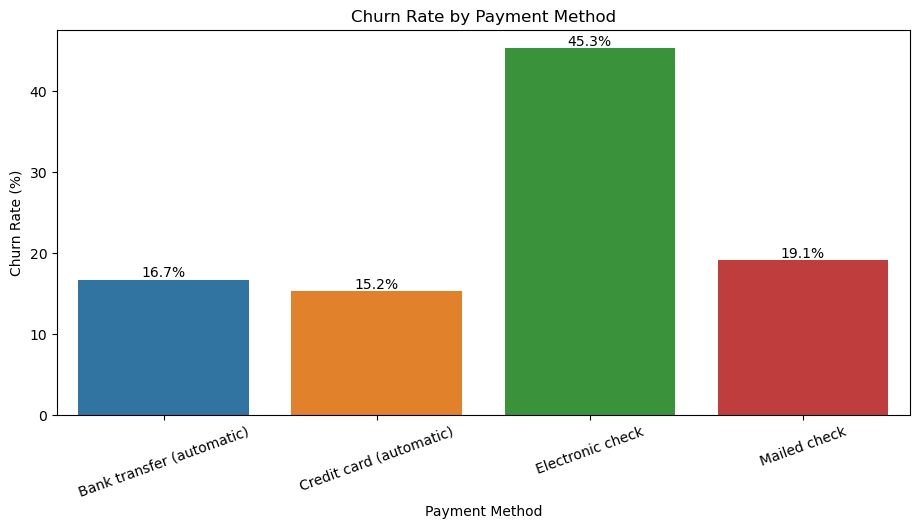

In [45]:
plt.figure(figsize=(11, 5))

ax = sns.barplot(
    x=payment_churn.index,
    y=payment_churn["Yes"]
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Payment Method Analysis — Interpretation

Churn rates vary considerably across payment methods.

Electronic check customers have the highest observed churn rate at 45.3%, while customers using automatic credit-card payments have a churn rate of 15.2%.

This indicates that payment method may be associated with customer churn and should be included as a potential predictive feature.

However, payment method alone should not be interpreted as a causal factor because it may be related to other customer characteristics such as tenure, contract type, and service usage.

In [46]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn.round(2))

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


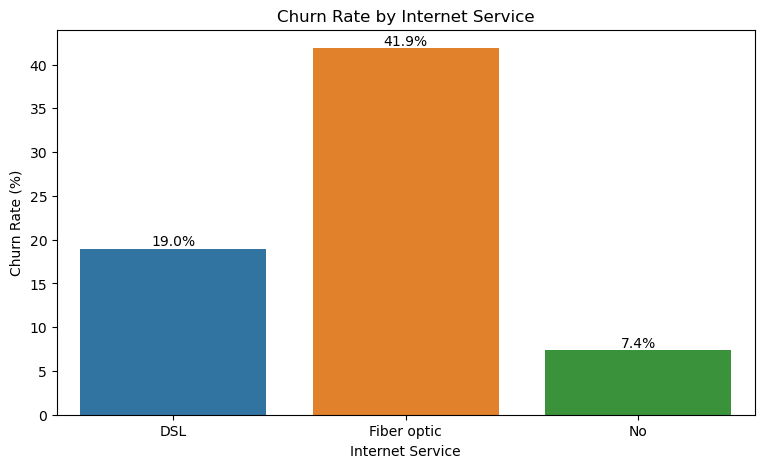

In [47]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=internet_churn.index,
    y=internet_churn["Yes"]
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Internet Service Analysis — Interpretation

Churn rates differ substantially across internet service categories.

Fiber optic customers have the highest observed churn rate at 41.9%, followed by DSL customers at 19.0%. Customers without internet service have a lower observed churn rate of 7.4%.

InternetService therefore appears to be an important variable for further churn analysis and will be included in the machine learning models.

These results represent associations within the dataset and do not establish a causal relationship between internet service type and churn.

In [48]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

print(partner_churn.round(2))

Churn       No    Yes
Partner              
No       67.04  32.96
Yes      80.34  19.66


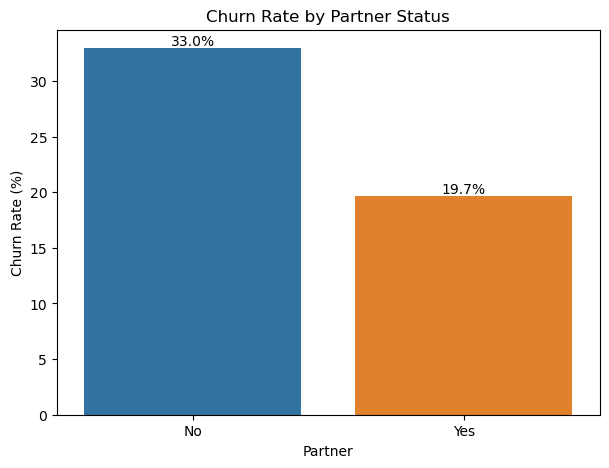

In [49]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=partner_churn.index,
    y=partner_churn["Yes"]
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [50]:
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

print(dependents_churn.round(2))

Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.55  15.45


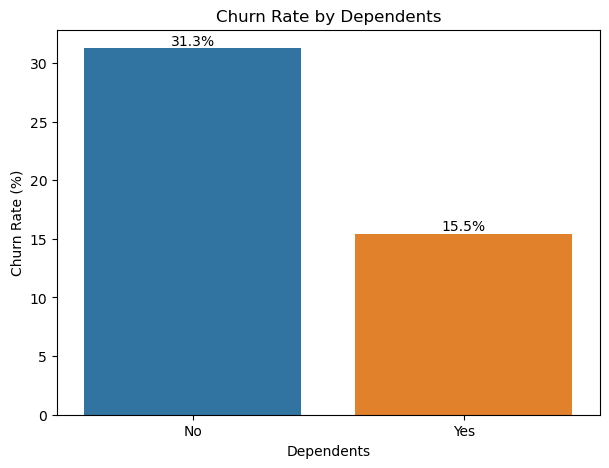

In [51]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=dependents_churn.index,
    y=dependents_churn["Yes"]
)

plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Partner and Dependents Analysis — Interpretation

Customers without a partner have an observed churn rate of 33.0%, compared with 19.7% for customers with a partner.

Similarly, customers without dependents have an observed churn rate of 31.3%, compared with 15.5% for customers with dependents.

These variables show associations with churn in the dataset and may provide useful information for customer segmentation and churn prediction. However, these relationships should be interpreted together with other variables rather than independently.

## EDA Summary — Key Findings

The exploratory analysis identified several important patterns associated with customer churn:

1. Overall churn:
   Approximately 26.5% of customers have churned.

2. Tenure:
   Churn is substantially higher among customers with shorter tenure. The 0–12 month group has a 47.4% churn rate, compared with 6.6% for customers with 61–72 months of tenure.

3. Contract:
   Month-to-month customers have a 42.7% churn rate, compared with 11.3% for one-year contracts and 2.8% for two-year contracts.

4. Monthly charges:
   Churned customers have a higher average monthly charge (74.44) than customers who stayed (61.27).

5. Payment method:
   Electronic check customers have a 45.3% churn rate, compared with 15.2% for automatic credit-card payments.

6. Internet service:
   Fiber optic customers have a 41.9% churn rate, compared with 19.0% for DSL and 7.4% for customers without internet service.

7. Partner and dependents:
   Customers without partners or dependents show higher observed churn rates than customers with these attributes.

These findings provide useful hypotheses about customer churn. Machine learning will now be used to evaluate multiple variables simultaneously and predict churn at the individual customer level.

In [52]:
segmentation_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_seg = df[segmentation_features].copy()

X_seg.head()

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


In [53]:
X_seg.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [54]:
scaler = StandardScaler()

X_seg_scaled = scaler.fit_transform(X_seg)

print(X_seg_scaled[:5])

[[-1.27744458 -1.16032292 -0.99261052]
 [ 0.06632742 -0.25962894 -0.17216471]
 [-1.23672422 -0.36266036 -0.9580659 ]
 [ 0.51425142 -0.74653546 -0.19367238]
 [-1.23672422  0.19736523 -0.93887444]]


In [55]:
inertia = []

K = range(2, 9)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_seg_scaled)
    
    inertia.append(kmeans.inertia_)

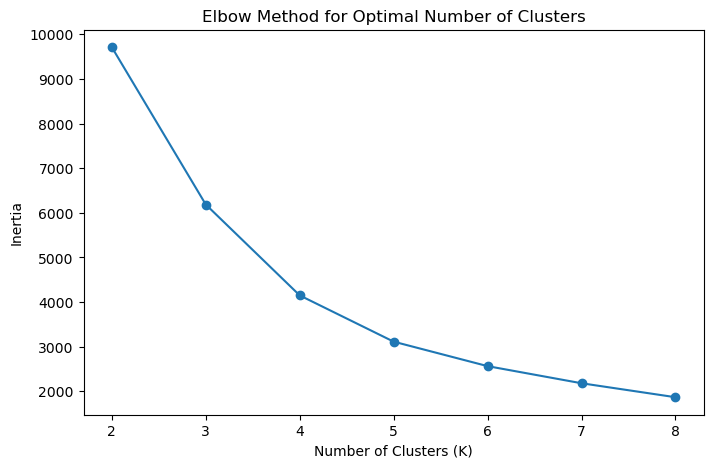

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(K, inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [57]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["CustomerSegment"] = kmeans.fit_predict(X_seg_scaled)

print(df["CustomerSegment"].value_counts().sort_index())

CustomerSegment
0    1703
1    1160
2    2276
3    1904
Name: count, dtype: int64


In [58]:
segment_profile = df.groupby("CustomerSegment")[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean()

print(segment_profile.round(2))

                 tenure  MonthlyCharges  TotalCharges
CustomerSegment                                      
0                 10.21           31.78        302.15
1                 53.57           34.91       1835.62
2                 15.42           80.78       1251.17
3                 59.53           93.31       5548.65


In [59]:
segment_profile = df.groupby("CustomerSegment").agg(
    CustomerCount=("customerID", "count"),
    AvgTenure=("tenure", "mean"),
    AvgMonthlyCharges=("MonthlyCharges", "mean"),
    AvgTotalCharges=("TotalCharges", "mean")
)

print(segment_profile.round(2))

                 CustomerCount  AvgTenure  AvgMonthlyCharges  AvgTotalCharges
CustomerSegment                                                              
0                         1703      10.21              31.78           302.15
1                         1160      53.57              34.91          1835.62
2                         2276      15.42              80.78          1251.17
3                         1904      59.53              93.31          5548.65


In [60]:
segment_churn = pd.crosstab(
    df["CustomerSegment"],
    df["Churn"],
    normalize="index"
) * 100

print(segment_churn.round(2))

Churn               No    Yes
CustomerSegment              
0                75.34  24.66
1                95.00   5.00
2                51.76  48.24
3                84.61  15.39


In [61]:
segment_profile["ChurnRate"] = segment_churn["Yes"]

print(segment_profile.round(2))

                 CustomerCount  AvgTenure  AvgMonthlyCharges  AvgTotalCharges  \
CustomerSegment                                                                 
0                         1703      10.21              31.78           302.15   
1                         1160      53.57              34.91          1835.62   
2                         2276      15.42              80.78          1251.17   
3                         1904      59.53              93.31          5548.65   

                 ChurnRate  
CustomerSegment             
0                    24.66  
1                     5.00  
2                    48.24  
3                    15.39  


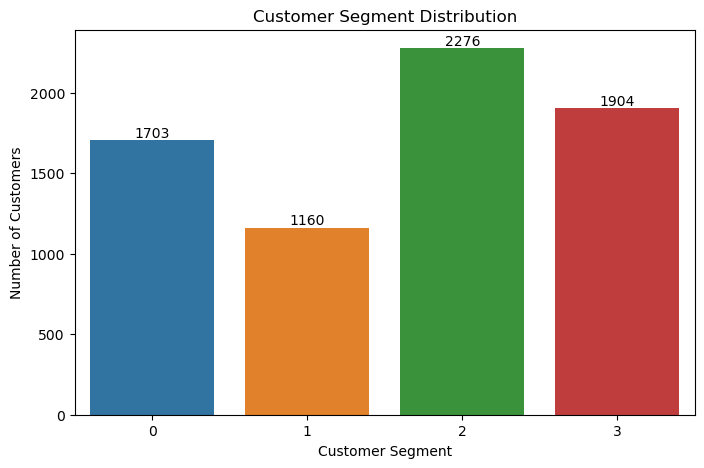

In [62]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="CustomerSegment"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

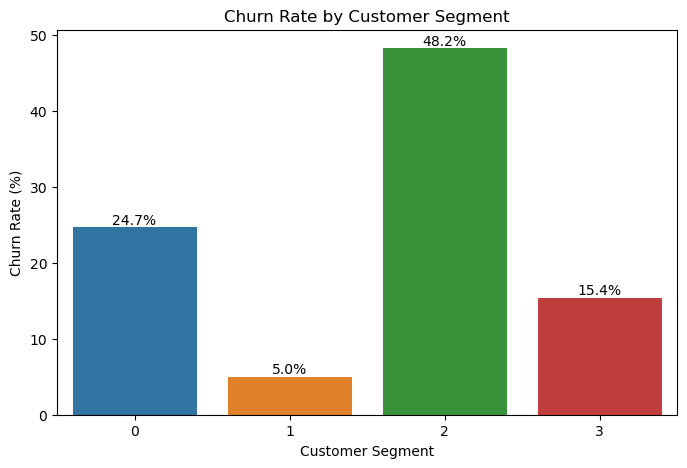

In [63]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=segment_churn.index,
    y=segment_churn["Yes"]
)

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Customer Segmentation — Interpretation

K-Means clustering was applied using tenure, MonthlyCharges, and TotalCharges after standardization.

Four customer segments were identified.

- Segment 0 represents relatively newer customers with lower monthly charges and a 24.7% observed churn rate.
- Segment 1 consists mainly of long-tenure customers with lower monthly charges and has a 5.0% observed churn rate.
- Segment 2 represents relatively newer customers with higher monthly charges and has the highest observed churn rate of 48.2%.
- Segment 3 consists of long-tenure customers with higher monthly charges and has a 15.4% observed churn rate.

The results indicate that customer behavior is influenced by combinations of characteristics rather than a single variable. In particular, the combination of relatively short tenure and higher monthly charges is associated with a higher observed churn rate in this segmentation.

In [64]:
df["ChurnFlag"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df["ChurnFlag"].value_counts()

ChurnFlag
0    5174
1    1869
Name: count, dtype: int64

In [65]:
features_to_drop = [
    "customerID",
    "Churn",
    "ChurnFlag",
    "TenureGroup",
    "MonthlyChargeGroup",
    "CustomerSegment"
]

X = df.drop(columns=features_to_drop)
y = df["ChurnFlag"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [66]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded X shape:", X.shape)

Encoded X shape: (7043, 30)


In [67]:
X.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [68]:
stratify=y

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5634
Testing samples: 1409


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training features:", X_train.shape[1])
print("Testing features:", X_test.shape[1])

Training samples: 5634
Testing samples: 1409
Training features: 30
Testing features: 30


In [71]:
scaler_ml = StandardScaler()

X_train_scaled = scaler_ml.fit_transform(X_train)
X_test_scaled = scaler_ml.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [72]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [73]:
y_pred_lr = logistic_model.predict(X_test_scaled)

y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [74]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")
print(f"ROC-AUC  : {roc_auc_lr:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy : 0.8062
Precision: 0.6573
Recall   : 0.5642
F1 Score : 0.6072
ROC-AUC  : 0.8418


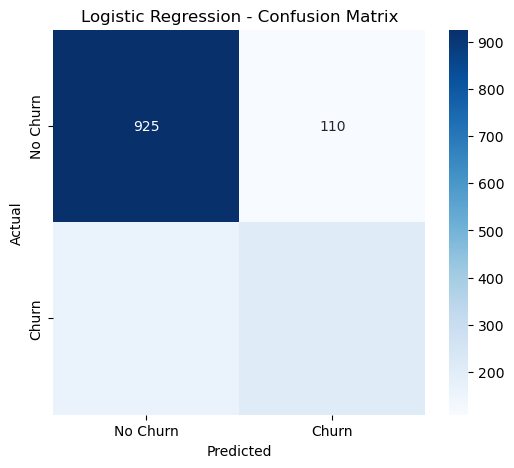

In [75]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [76]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [77]:
y_pred_dt = decision_tree.predict(X_test)

y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

print("Decision Tree predictions generated successfully!")

Decision Tree predictions generated successfully!


In [78]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"ROC-AUC  : {roc_auc_dt:.4f}")

Decision Tree Performance
-------------------------
Accuracy : 0.7346
Precision: 0.5000
Recall   : 0.8075
F1 Score : 0.6176
ROC-AUC  : 0.8308


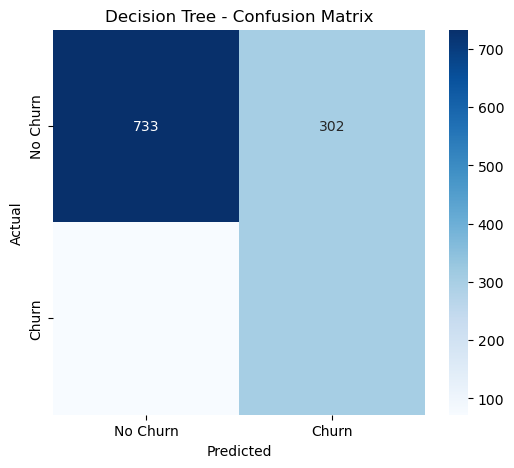

In [79]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [80]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt
    ],
    "Precision": [
        precision_lr,
        precision_dt
    ],
    "Recall": [
        recall_lr,
        recall_dt
    ],
    "F1 Score": [
        f1_lr,
        f1_dt
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_dt
    ]
})

print(model_comparison.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8062     0.6573  0.5642    0.6072   0.8418
1        Decision Tree    0.7346     0.5000  0.8075    0.6176   0.8308


In [81]:
model_comparison.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


## Customer Risk Dataset

The Decision Tree model generates churn predictions and churn probabilities for customers in the test dataset.

The predicted churn probability will be used to classify customers into different risk levels for further retention analysis.

In [82]:
risk_df = X_test.copy()

risk_df["ActualChurn"] = y_test.values
risk_df["PredictedChurn"] = y_pred_dt
risk_df["ChurnProbability"] = y_prob_dt

risk_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,ActualChurn,PredictedChurn,ChurnProbability
437,0,72,114.05,8468.20,True,True,True,True,False,True,...,True,False,True,True,True,False,False,0,0,0.000000
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,True,False,False,True,True,False,False,0,1,0.843595
2235,0,41,78.35,3211.20,False,True,True,True,False,True,...,False,True,False,True,True,False,False,0,0,0.047378
4460,0,18,78.20,1468.75,True,True,False,True,False,False,...,False,False,False,False,False,True,False,0,1,0.729375
3761,0,72,82.65,5919.35,False,True,False,True,False,True,...,True,False,True,True,True,False,False,0,0,0.059745


In [83]:
def risk_category(probability):
    if probability >= 0.60:
        return "High Risk"
    elif probability >= 0.30:
        return "Medium Risk"
    else:
        return "Low Risk"

In [84]:
risk_df["RiskLevel"] = risk_df["ChurnProbability"].apply(risk_category)

risk_df["RiskLevel"].value_counts()

RiskLevel
Low Risk       557
Medium Risk    433
High Risk      419
Name: count, dtype: int64

## High-Risk Customer Identification

Customers classified as High Risk are extracted from the test dataset for targeted retention analysis.

In [85]:
high_risk_customers = risk_df[
    risk_df["RiskLevel"] == "High Risk"
].copy()

print("Number of high-risk customers:", len(high_risk_customers))

Number of high-risk customers: 419


## Ranking High-Risk Customers

High-risk customers are sorted by predicted churn probability in descending order so that customers with the highest predicted risk appear first.

In [86]:
high_risk_customers = high_risk_customers.sort_values(
    "ChurnProbability",
    ascending=False
)

high_risk_customers.head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,ActualChurn,PredictedChurn,ChurnProbability,RiskLevel
2221,0,71,64.05,4492.90,False,True,True,True,False,False,...,False,True,False,True,False,False,0,1,1.000000,High Risk
5905,0,1,85.00,85.00,True,False,False,True,False,False,...,False,False,True,False,True,False,0,1,0.942246,High Risk
2194,0,1,79.50,79.50,True,False,False,True,False,False,...,False,False,True,False,True,False,1,1,0.942246,High Risk
2927,0,1,69.90,69.90,True,False,False,True,False,False,...,False,False,True,False,True,False,0,1,0.942246,High Risk
5100,0,1,75.30,75.30,False,False,False,True,False,False,...,False,False,False,False,True,False,1,1,0.942246,High Risk
2911,0,1,73.50,73.50,False,False,False,True,False,False,...,False,False,False,False,False,False,1,1,0.942246,High Risk
1807,0,1,76.35,76.35,False,False,False,True,False,False,...,False,False,False,False,True,False,1,1,0.942246,High Risk
5393,0,1,70.60,70.60,False,False,False,True,False,False,...,False,False,True,False,True,False,1,1,0.942246,High Risk
2510,0,1,74.25,74.25,True,False,False,True,False,True,...,False,False,True,False,False,True,1,1,0.942246,High Risk
4585,1,1,85.05,85.05,False,False,False,True,False,True,...,False,False,True,False,True,False,1,1,0.942246,High Risk


## Final High-Risk Customer Table

A clean table is created containing the key customer attributes, predicted churn probability, risk level, and customer segment. This table will be used as the main output for retention analysis.

In [87]:
test_indices = X_test.index

original_test = df.loc[test_indices].copy()

print("Original test customer data:", original_test.shape)

Original test customer data: (1409, 25)


In [88]:
final_risk_data = original_test.copy()

final_risk_data["ChurnProbability"] = y_prob_dt
final_risk_data["PredictedChurn"] = y_pred_dt
final_risk_data["RiskLevel"] = risk_df["RiskLevel"].values

print(final_risk_data.shape)

(1409, 28)


In [89]:
final_risk_table = final_risk_data[
    [
        "customerID",
        "ChurnProbability",
        "RiskLevel",
        "CustomerSegment",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "InternetService",
        "PaymentMethod"
    ]
].copy()

final_risk_table.head(10)

,customerID,ChurnProbability,RiskLevel,CustomerSegment,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod
437,4376-KFVRS,0.000000,Low Risk,3,72,114.05,8468.20,Two year,Fiber optic,Credit card (automatic)
2280,2754-SDJRD,0.843595,High Risk,2,8,100.15,908.55,Month-to-month,Fiber optic,Credit card (automatic)
2235,9917-KWRBE,0.047378,Low Risk,2,41,78.35,3211.20,One year,DSL,Credit card (automatic)
4460,0365-GXEZS,0.729375,High Risk,2,18,78.20,1468.75,Month-to-month,Fiber optic,Electronic check
3761,9385-NXKDA,0.059745,Low Risk,3,72,82.65,5919.35,Two year,DSL,Credit card (automatic)
5748,4686-UXDML,0.582306,Medium Risk,2,21,99.85,1992.55,Month-to-month,Fiber optic,Credit card (automatic)
3568,2227-JRSJX,0.582306,Medium Risk,2,21,99.15,1956.40,Month-to-month,Fiber optic,Bank transfer (automatic)
2976,4830-FAXFM,0.325641,Medium Risk,0,19,24.10,439.20,Month-to-month,No,Credit card (automatic)
5928,1830-IPXVJ,0.000000,Low Risk,1,61,19.75,1311.60,Two year,No,Credit card (automatic)
1639,4690-LLKUA,0.325641,Medium Risk,0,17,45.05,770.60,Month-to-month,DSL,Electronic check


## Churn Probability Percentage

The predicted churn probabilities are converted into percentage values to make the risk results easier to interpret for business users.

In [90]:
final_risk_table["ChurnProbability"] = (
    final_risk_table["ChurnProbability"] * 100
).round(2)

final_risk_table.head(10)

,customerID,ChurnProbability,RiskLevel,CustomerSegment,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod
437,4376-KFVRS,0.00,Low Risk,3,72,114.05,8468.20,Two year,Fiber optic,Credit card (automatic)
2280,2754-SDJRD,84.36,High Risk,2,8,100.15,908.55,Month-to-month,Fiber optic,Credit card (automatic)
2235,9917-KWRBE,4.74,Low Risk,2,41,78.35,3211.20,One year,DSL,Credit card (automatic)
4460,0365-GXEZS,72.94,High Risk,2,18,78.20,1468.75,Month-to-month,Fiber optic,Electronic check
3761,9385-NXKDA,5.97,Low Risk,3,72,82.65,5919.35,Two year,DSL,Credit card (automatic)
5748,4686-UXDML,58.23,Medium Risk,2,21,99.85,1992.55,Month-to-month,Fiber optic,Credit card (automatic)
3568,2227-JRSJX,58.23,Medium Risk,2,21,99.15,1956.40,Month-to-month,Fiber optic,Bank transfer (automatic)
2976,4830-FAXFM,32.56,Medium Risk,0,19,24.10,439.20,Month-to-month,No,Credit card (automatic)
5928,1830-IPXVJ,0.00,Low Risk,1,61,19.75,1311.60,Two year,No,Credit card (automatic)
1639,4690-LLKUA,32.56,Medium Risk,0,17,45.05,770.60,Month-to-month,DSL,Electronic check


## Export High-Risk Customer Results

The final customer risk table is exported as a CSV file for business analysis and retention planning.

In [91]:
final_risk_table.to_csv(
    "../outputs/high_risk_customers.csv",
    index=False
)

print("High-risk customer file saved successfully!")

High-risk customer file saved successfully!


## High-Risk Customers by Customer Segment

The distribution of high-risk customers across the K-Means customer segments is analyzed to understand which customer segments require greater attention in retention planning.

In [92]:
high_risk_segment = (
    final_risk_data[
        final_risk_data["RiskLevel"] == "High Risk"
    ]["CustomerSegment"]
    .value_counts()
    .sort_index()
)

print(high_risk_segment)

CustomerSegment
0     88
2    288
3     43
Name: count, dtype: int64


## High-Risk Customers by Contract Type

The contract types of high-risk customers are analyzed to understand the distribution of predicted churn risk across different contract arrangements.

In [93]:
high_risk_contract = (
    final_risk_data[
        final_risk_data["RiskLevel"] == "High Risk"
    ]["Contract"]
    .value_counts()
)

print(high_risk_contract)

Contract
Month-to-month    417
Two year            2
Name: count, dtype: int64


## High-Risk Customers by Internet Service

The internet service types of high-risk customers are analyzed to understand how predicted churn risk is distributed across different service categories.

In [94]:
high_risk_internet = (
    final_risk_data[
        final_risk_data["RiskLevel"] == "High Risk"
    ]["InternetService"]
    .value_counts()
)

print(high_risk_internet)

InternetService
Fiber optic    324
DSL             95
Name: count, dtype: int64


## High-Risk Customers by Payment Method

The payment methods used by high-risk customers are analyzed to identify payment-related patterns among customers with elevated predicted churn risk.

In [95]:
high_risk_payment = (
    final_risk_data[
        final_risk_data["RiskLevel"] == "High Risk"
    ]["PaymentMethod"]
    .value_counts()
)

print(high_risk_payment)

PaymentMethod
Electronic check             296
Mailed check                  66
Credit card (automatic)       32
Bank transfer (automatic)     25
Name: count, dtype: int64


## High-Risk Customers by Monthly Charges

The monthly charges of high-risk customers are summarized to understand the typical billing level associated with customers having elevated predicted churn risk.

In [96]:
high_risk_charges = (
    final_risk_data[
        final_risk_data["RiskLevel"] == "High Risk"
    ]["MonthlyCharges"]
)

print("Average Monthly Charges:",
      round(high_risk_charges.mean(), 2))

print("Median Monthly Charges:",
      round(high_risk_charges.median(), 2))

print("Minimum Monthly Charges:",
      round(high_risk_charges.min(), 2))

print("Maximum Monthly Charges:",
      round(high_risk_charges.max(), 2))

Average Monthly Charges: 76.22
Median Monthly Charges: 78.3
Minimum Monthly Charges: 24.2
Maximum Monthly Charges: 114.1


## High-Risk Customers by Tenure

The tenure distribution of high-risk customers is analyzed to understand how long customers with elevated predicted churn risk have been with the company.

In [97]:
high_risk_tenure = (
    final_risk_data[
        final_risk_data["RiskLevel"] == "High Risk"
    ]["tenure"]
)

print("Average Tenure:",
      round(high_risk_tenure.mean(), 2))

print("Median Tenure:",
      round(high_risk_tenure.median(), 2))

print("Minimum Tenure:",
      high_risk_tenure.min())

print("Maximum Tenure:",
      high_risk_tenure.max())

Average Tenure: 13.1
Median Tenure: 5.0
Minimum Tenure: 1
Maximum Tenure: 72


## High-Risk Customer Profile Summary

The key characteristics of high-risk customers are summarized to support targeted customer retention analysis.

In [98]:
high_risk_profile = {
    "Total High-Risk Customers": len(final_risk_data[
        final_risk_data["RiskLevel"] == "High Risk"
    ]),
    "Average Tenure": round(
        final_risk_data[
            final_risk_data["RiskLevel"] == "High Risk"
        ]["tenure"].mean(), 2
    ),
    "Median Tenure": round(
        final_risk_data[
            final_risk_data["RiskLevel"] == "High Risk"
        ]["tenure"].median(), 2
    ),
    "Average Monthly Charges": round(
        final_risk_data[
            final_risk_data["RiskLevel"] == "High Risk"
        ]["MonthlyCharges"].mean(), 2
    )
}

print(high_risk_profile)

{'Total High-Risk Customers': 419, 'Average Tenure': 13.1, 'Median Tenure': 5.0, 'Average Monthly Charges': 76.22}


## Risk Level Distribution

The distribution of customers across Low, Medium, and High Risk categories is visualized to provide an overview of the predicted churn risk within the test dataset.

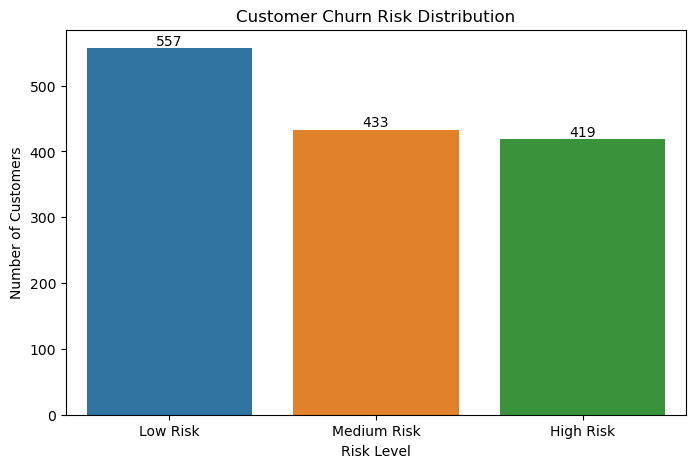

In [99]:
risk_counts = risk_df["RiskLevel"].value_counts().reindex(
    ["Low Risk", "Medium Risk", "High Risk"]
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Saving Risk Distribution Chart

The customer churn risk distribution chart is saved as an image for use in the project report and GitHub documentation.

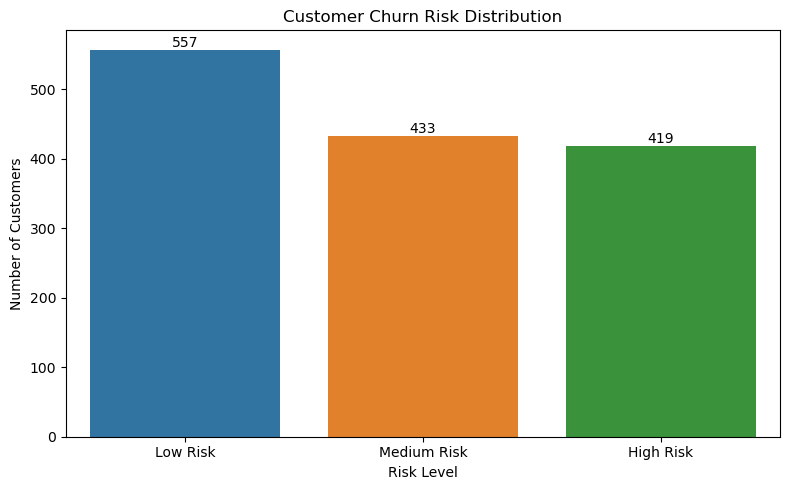

In [100]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig("../images/risk_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

## Final Project Insights

The customer churn analysis identified important patterns related to customer tenure, contract type, monthly charges, payment method, internet service, customer segmentation, and predicted churn risk.

In [101]:
print("FINAL PROJECT INSIGHTS")
print("-" * 40)

print("Total Customers:", len(df))
print("High-Risk Customers:", 419)
print("Average Tenure of High-Risk Customers:", 13.1, "months")
print("Average Monthly Charges of High-Risk Customers:", 76.22)
print("Highest Churn Segment: Segment 2")
print("Highest Risk Contract Type: Month-to-month")
print("Highest Risk Internet Service: Fiber optic")
print("Highest Risk Payment Method: Electronic check")

FINAL PROJECT INSIGHTS
----------------------------------------
Total Customers: 7043
High-Risk Customers: 419
Average Tenure of High-Risk Customers: 13.1 months
Average Monthly Charges of High-Risk Customers: 76.22
Highest Churn Segment: Segment 2
Highest Risk Contract Type: Month-to-month
Highest Risk Internet Service: Fiber optic
Highest Risk Payment Method: Electronic check


## Saving Final Project Insights

The key findings from the customer churn analysis are saved in a text file for documentation and reporting purposes.

In [102]:
insights = """
FINAL PROJECT INSIGHTS
----------------------

Total Customers: 7043
High-Risk Customers: 419
Average Tenure of High-Risk Customers: 13.1 months
Average Monthly Charges of High-Risk Customers: 76.22

Highest Churn Segment: Segment 2
Highest Risk Contract Type: Month-to-month
Highest Risk Internet Service: Fiber optic
Highest Risk Payment Method: Electronic check
"""

with open("../reports/final_project_insights.txt", "w") as file:
    file.write(insights)

print("Final project insights saved successfully.")

Final project insights saved successfully.


In [103]:
print("PROJECT 2 NOTEBOOK CHECK")
print("-" * 40)
print("Dataset Shape:", df.shape)
print("Model Comparison Shape:", model_comparison.shape)
print("High-Risk Customers:", len(high_risk_customers))
print("Risk Distribution:")
print(risk_df["RiskLevel"].value_counts())
print("-" * 40)
print("Notebook execution check completed.")

PROJECT 2 NOTEBOOK CHECK
----------------------------------------
Dataset Shape: (7043, 25)
Model Comparison Shape: (2, 6)
High-Risk Customers: 419
Risk Distribution:
RiskLevel
Low Risk       557
Medium Risk    433
High Risk      419
Name: count, dtype: int64
----------------------------------------
Notebook execution check completed.


In [104]:
!python ../src/customer_churn_model.py

Logistic Regression
Accuracy: 0.8062
Precision: 0.6573
Recall: 0.5642
F1 Score: 0.6072
ROC-AUC: 0.8418

Decision Tree
Accuracy: 0.7346
Precision: 0.5
Recall: 0.8075
F1 Score: 0.6176
ROC-AUC: 0.8308
